In [1]:
import itertools

import ase
import numpy as np
import pyiron_workflow as pwf
from ase.calculators import emt
from matplotlib import pyplot as plt
from pyiron_workflow_atomistics import engine as engine_mod

from demonstrators import gb_nodes

In [2]:
engine = engine_mod.ASEEngine(
    EngineInput=None,
    calculator=emt.EMT(),
    working_directory="demo_runs",
    record_interval=100,
)

## Grain boundary segregation

In [3]:
segregation_wf = pwf.node(gb_nodes.volumetric_segregation)
segregation_wf.validate(do_ontology=False)  # Need to encapsulate for-loops

Type validation for 'volumetric_segregation' (valid=False, complete=False):
	unfulfilled edges:
		for_each_0.solute_excess_volumes->solute_excess_volumes
		for_each_0.solute_segregation_energies->solute_segregation_energies
	subreports:
	Type validation for 'volumetric_segregation.get_relaxed_bulk_0' (valid=False, complete=False):
		invalid edges:
			repetitions->create_supercell_0.supercell_repeats
		unfulfilled edges:
			calculate_with_input_0.relaxed_structure->relaxed_structure
			calculate_with_input_0.relaxed_energy->relaxed_energy
		subreports:
		constant_0: <NOT PARSEABLE>
		Type validation for 'volumetric_segregation.get_relaxed_bulk_0.calculate_with_input_0' (valid=True, complete=False):
			unfulfilled edges:
				with_calc_input_0.output_0->calculate_0.engine
			subreports:
			constant_0: <NOT PARSEABLE>
			constant_1: <NOT PARSEABLE>
		constant_1: <NOT PARSEABLE>
	Type validation for 'volumetric_segregation.get_relaxed_gb_0' (valid=False, complete=False):
		invalid edges:
		

In [4]:
segregation_run = segregation_wf.run(
    host="Al",
    solutes=["Cu", "Ag", "Au", "Ni"],
    bulk_reps=3,
    gb_parameters=gb_nodes.GBParameters(
        axis=(0, 0, 1),
        sigma=5,
        plane=(1, 2, 0),
        grain_thickness=3,
        supercell_repeats=(2, 1, 3),
    ),
    engine=engine.with_working_directory("grain_boundary"),
    clean_minimize_input=engine_mod.CalcInputMinimize(relax_cell=True),
    solute_minimize_input=engine_mod.CalcInputMinimize(relax_cell=False),
)

      Step     Time          Energy          fmax
BFGS:    0 14:39:58       -0.162221       17.473727
BFGS:    1 14:39:58       79.415321      272.358319
BFGS:    2 14:39:58       -0.521633        2.202365
BFGS:    3 14:39:58       -0.527256        0.251641
BFGS:    4 14:39:58       -0.527330        0.000523
      Step     Time          Energy          fmax
BFGS:    0 14:39:59       61.510343      209.760646
BFGS:    1 14:40:00       98.220683      765.675330
BFGS:    2 14:40:01       83.944394      447.190849
BFGS:    3 14:40:01      175.630701     1561.983749
BFGS:    4 14:40:02       36.361849      322.850076
BFGS:    5 14:40:03       25.567185      181.074748
BFGS:    6 14:40:03       17.413970      130.652223
BFGS:    7 14:40:04       15.927161      136.451429
BFGS:    8 14:40:05       13.278093       22.709409
BFGS:    9 14:40:05       12.787522       17.918262
BFGS:   10 14:40:06       12.539565       29.864462
BFGS:   11 14:40:07       12.421611       45.569787
BFGS:   12 14:40

/var/folders/nn/6kd6nhmj2rx7610kd9r_8h0m0000gn/T/ipykernel_16478/1670936400.py:132: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


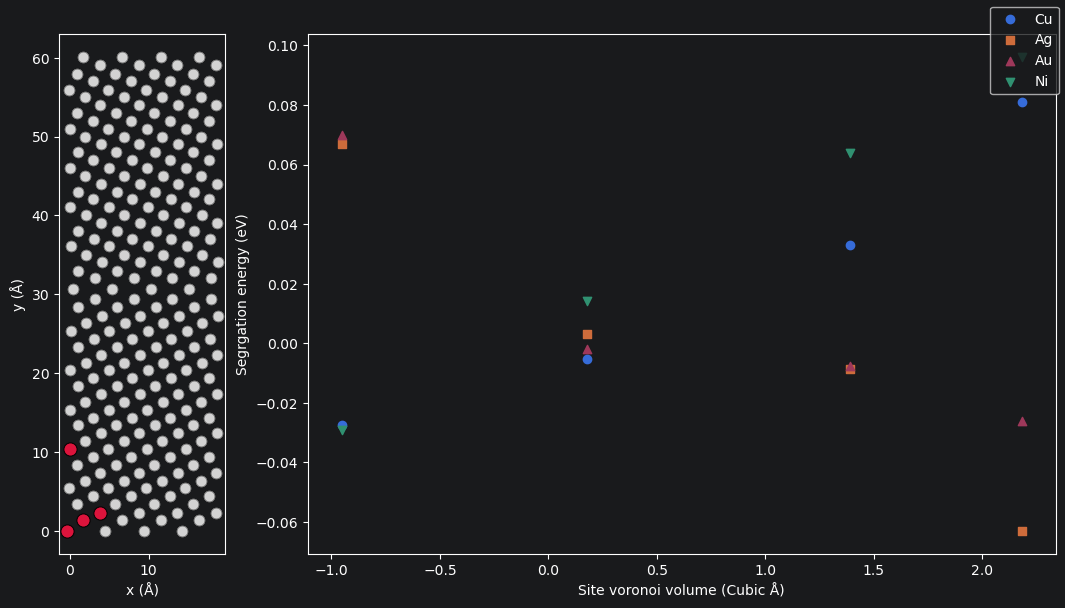

In [5]:
def plot_energies(
    solutes: list[str],
    excess_volumes: list[list[float]],
    energies: list[list[float]],
    marker_cycle: itertools.cycle,
    ax: plt.Axes | None = None,
):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    for solute, volumes, energies in zip(solutes, excess_volumes, energies, strict=True):
        ax.scatter(volumes, energies, label=solute, marker=next(marker_cycle))
        ax.set_xlabel("Site voronoi volume (Cubic Å)")
        ax.set_ylabel("Segrgation energy (eV)")

    return ax


def plot_structure(
    structure: ase.Atoms,
    sites: list[int],
    site_excess_volumes: list[float],
    label_sites: bool = False,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Plot the xy projection of `structure`, highlighting `sites`.

    Args:
        structure: The structure to project onto the xy plane.
        sites: Indices of the special sites (columns) to highlight.
        site_volumes: One value per entry of `sites`, annotated to 2 d.p.
    """
    if len(sites) != len(site_excess_volumes):
        raise ValueError(
            f"len(sites)={len(sites)} != len(site_volumes)={len(site_excess_volumes)}"
        )

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    positions = structure.get_positions()
    mask = np.zeros(len(structure), dtype=bool)
    mask[np.asarray(sites, dtype=int)] = True

    ax.scatter(
        positions[~mask, 0],
        positions[~mask, 1],
        s=60,
        c="lightgrey",
        edgecolors="dimgrey",
        linewidths=0.5,
        zorder=2,
    )
    ax.scatter(
        positions[mask, 0],
        positions[mask, 1],
        s=90,
        c="crimson",
        edgecolors="black",
        linewidths=0.7,
        zorder=3,
    )

    if label_sites:
        for index, volume in zip(sites, site_excess_volumes, strict=True):
            ax.annotate(
                # f"{volume:.2f}",
                f"{index}",
                xy=positions[index, :2],
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                zorder=4,
                color="blue",
            )

    ax.set_aspect("equal")
    ax.set_xlabel("x (Å)")
    ax.set_ylabel("y (Å)")
    return ax


def plot_structure_and_energies(
    structure: ase.Atoms,
    sites: list[int],
    excess_volumes: list[list[float]],
    solutes: list[str],
    energies: list[list[float]],
    panel_height: float = 6.0,
    energy_width_ratio: float = 4.5,
) -> plt.Figure:
    """Draw the structure projection and the E(V) curves side by side."""
    fig, (ax_structure, ax_energies) = plt.subplots(
        1,
        2,
        figsize=(panel_height, panel_height),  # overwritten below
        gridspec_kw={"width_ratios": [1.0, energy_width_ratio]},
        layout="constrained",
    )

    plot_structure(structure, sites, excess_volumes[0], ax=ax_structure)
    plot_energies(
        solutes,
        excess_volumes,
        energies,
        marker_cycle=itertools.cycle("os^vD*"),
        ax=ax_energies,
    )

    # Rendered aspect (height / width) of the structure panel, taken from the
    # data limits *after* plotting so margins are included.
    x_lo, x_hi = ax_structure.get_xlim()
    y_lo, y_hi = ax_structure.get_ylim()
    aspect = abs(y_hi - y_lo) / abs(x_hi - x_lo)

    ax_structure.set_box_aspect(aspect)
    ax_energies.set_box_aspect(aspect / energy_width_ratio)

    structure_width = panel_height / aspect
    fig.set_size_inches(structure_width * (1.0 + energy_width_ratio), panel_height)
    return fig

fig = plot_structure_and_energies(
    segregation_run.outputs.gb_structure,
    segregation_run.outputs.gb_sites,
    segregation_run.outputs.solute_excess_volumes,
    segregation_run.result.input_ports["solutes"].value,
    segregation_run.outputs.solute_segregation_energies,
)

fig.legend()
fig.show()

We find copper and nickle preferring compressive sites, while silver and gold prefer expansive sites.

The site with near-zero excess volume is the bulk-like site; nearness of volume differential and segregation energy to zero give a proxy for how well-converged results are with respect to system size. In this case, we see that both energies and volumes at the bulk-like site are small but not trivial compared to GB sites.